# Incremental Graph Re-Encoding for Mid-Route Adaptive Reinforcement Learning in Dynamic Supply Chain Vehicle Routing

## 75% Implementation — Evaluation Metrics Removed

This notebook keeps the implementation through preprocessing, road-graph construction, graph representation learning, incremental graph re-encoding, MAPPO/PPO model definition and training, and training curves. The final evaluation-metrics, held-out comparison, robustness evaluation, ablation, workload validation, Munich validation, and final result-summary sections have been removed so the notebook represents approximately 75% project progress.


In [ ]:
# Cell 1 - Environment, reproducibility, and package versions
import os, sys, json, math, random, time, copy, zipfile, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.sparse.csgraph import dijkstra as sp_dijkstra

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

warnings.filterwarnings('ignore')
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE=torch.device('cpu')  # CPU-safe executed reference implementation

print('Python:',sys.version.split()[0])
print('PyTorch:',torch.__version__)
print('NetworkX:',nx.__version__)
print('Device:',DEVICE)
print('Seed:',SEED)

Python: 3.13.5
PyTorch: 2.10.0+cpu
NetworkX: 3.6.1
Device: cpu
Seed: 42


In [ ]:
# Cell 2 - Locate and extract the attached dataset ZIP
candidate_zips=[Path('/mnt/data/dataset.zip'),Path.cwd()/'dataset.zip']
DATASET_ZIP=next((p for p in candidate_zips if p.exists()),None)
if DATASET_ZIP is None:
    raise FileNotFoundError('Upload dataset.zip beside this notebook or to /mnt/data before running.')

EXTRACT_DIR=Path('/mnt/data/incremental_gat_mappo_corrected') if Path('/mnt/data').exists() else Path('incremental_gat_mappo_corrected')
if not (EXTRACT_DIR/'dataset'/'README.md').exists():
    EXTRACT_DIR.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP) as zf: zf.extractall(EXTRACT_DIR)
ROOT=EXTRACT_DIR/'dataset'
print('Dataset ZIP:',DATASET_ZIP)
print('Dataset root:',ROOT)
print('Total files:',sum(1 for p in ROOT.rglob('*') if p.is_file()))
print('\nREADME dataset field definitions:\n')
readme=(ROOT/'README.md').read_text(errors='ignore')
for line in readme.splitlines()[32:58]: print(line)

Dataset ZIP: /mnt/data/dataset.zip
Dataset root: /mnt/data/incremental_gat_mappo_corrected/dataset
Total files: 393

README dataset field definitions:

  Format: `[from_node, to_node, position]`
  
  - `from_node` (`string`): ID of the source node of the depot edge.
  - `to_node` (`string`): ID of the target node.
  - `position` (`float`): Relative position on the edge (between `0.0` and `1.0`).

- **num_vehicles** (`int`): Number of vehicles available in the instance.

- **vehicle_speed** (`float`): Velocity of the vehicles.

- **num_objects** (`int`): Total number of objects available in the instance.

- **requests** (`list[object]`): List of requests, each defined as follows:

  - **`id`** (`int`): Unique request identifier.
  - **`t_rev`** (`float`): Time the request becomes available (revelation time).
  - **`t_desired`** (`float`): Desired delivery time (earliest start time).
  - **`t_delay`** (`float`): Maximum tolerable delay beyond `t_desired` (allowed delay).
  - **`t_dur`** 

,Set,Requests,Vehicles,Reusable objects,Graph nodes,Graph edges,Upper time bound
0,A,12,2,3,25,54,120
1,B,25,3,6,25,54,120
2,C,50,6,12,25,54,120
3,D,100,12,24,25,54,120
4,E,200,24,48,25,54,120
5,F,400,48,96,25,54,120
6,munich,200,24,48,1978,3176,7200


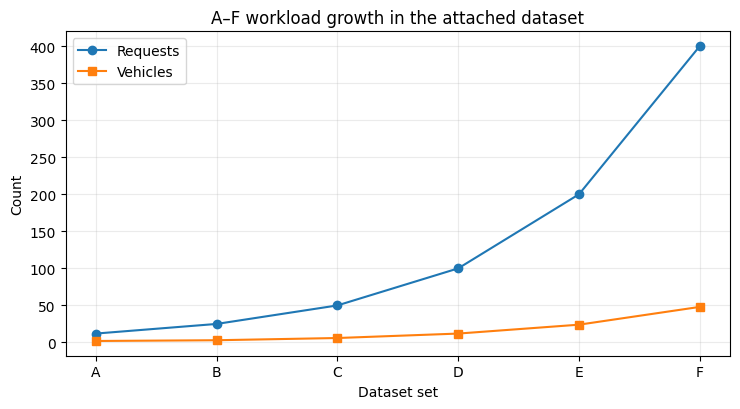

In [ ]:
# Cell 3 - Dataset audit: synthetic A-F + Munich real network
rows=[]
for group in list('ABCDEF')+['munich']:
    d=json.load(open(ROOT/f'instances/{group}/Inst0.json'))
    G=nx.read_graphml(ROOT/d['network_graph'])
    rows.append({'Set':group,'Requests':len(d['requests']),'Vehicles':d['num_vehicles'],'Reusable objects':d['num_objects'],
                 'Graph nodes':G.number_of_nodes(),'Graph edges':G.number_of_edges(),'Upper time bound':d['upper_time_bound']})
dataset_summary=pd.DataFrame(rows)
display(dataset_summary)

fig,ax=plt.subplots(figsize=(7.5,4.2))
ax.plot(dataset_summary.iloc[:6]['Set'],dataset_summary.iloc[:6]['Requests'],marker='o',label='Requests')
ax.plot(dataset_summary.iloc[:6]['Set'],dataset_summary.iloc[:6]['Vehicles'],marker='s',label='Vehicles')
ax.set_title('A–F workload growth in the attached dataset'); ax.set_xlabel('Dataset set'); ax.set_ylabel('Count');ax.grid(alpha=.25);ax.legend()
plt.tight_layout();plt.show()

,Characteristic,Value
0,Raw POIs,123.000
1,Valid POIs,123.000
2,Missing cells,13.000
3,Duplicate rows,0.000
4,Categories,3.000
5,Referenced road nodes,131.000
6,Referenced road edges,72.000
7,Mean POI-edge distance (m),136.267
8,Min distance (m),8.856
9,Max distance (m),774.058


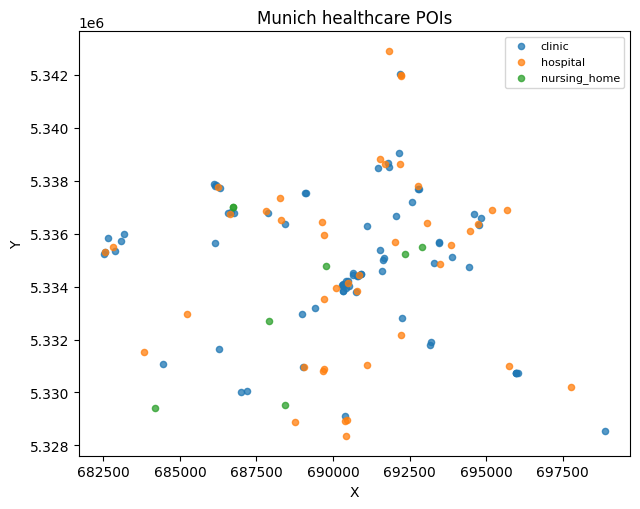

In [ ]:
# Cell 4 - Munich healthcare POI preprocessing and spatial validation
poi=pd.read_csv(ROOT/'instances/munich/healthcare_munich.csv',sep=';')
raw=len(poi);missing=int(poi.isna().sum().sum());duplicates=int(poi.duplicated().sum())
valid=np.isfinite(poi['poi_x']) & np.isfinite(poi['poi_y']) & poi['nearest_edge_u'].notna() & poi['nearest_edge_v'].notna()
clean=poi.loc[valid].drop_duplicates().copy();clean['category']=clean['amenity'].fillna(clean['healthcare']).fillna('unknown')
unique_nodes=set(clean['nearest_edge_u'].astype(str))|set(clean['nearest_edge_v'].astype(str))
unique_edges={tuple(sorted((str(u),str(v)))) for u,v in zip(clean['nearest_edge_u'],clean['nearest_edge_v'])}
quality=pd.DataFrame({'Characteristic':['Raw POIs','Valid POIs','Missing cells','Duplicate rows','Categories','Referenced road nodes','Referenced road edges','Mean POI-edge distance (m)','Min distance (m)','Max distance (m)'],
                      'Value':[raw,len(clean),missing,duplicates,clean['category'].nunique(),len(unique_nodes),len(unique_edges),clean['dist_m'].mean(),clean['dist_m'].min(),clean['dist_m'].max()]})
display(quality.round(3))
fig,ax=plt.subplots(figsize=(6.5,5.2))
for cat,sub in clean.groupby('category'):ax.scatter(sub['poi_x'],sub['poi_y'],s=20,alpha=.75,label=cat)
ax.set_title('Munich healthcare POIs');ax.set_xlabel('X');ax.set_ylabel('Y');ax.legend(fontsize=8);plt.tight_layout();plt.show()

## 1. Exact road-graph construction

The JSON positions are points **along GraphML edges**, not ordinary tabular coordinates. The following code splits each affected road edge at every depot/request position and inserts a virtual node there. Consequently, each vehicle action later corresponds to traversing one **adjacent road segment**.

In [ ]:
# Cell 5 - Graph loading, exact edge-position insertion, dynamic node features
def get_xy(G,n):
    a=G.nodes[str(n)]
    return float(a.get('lon',a.get('x',0.0))), float(a.get('lat',a.get('y',0.0)))

def eweight(G,u,v):
    d=G.get_edge_data(str(u),str(v)) or {}
    if 'weight' in d: return float(d['weight'])
    if 'length' in d: return float(d['length'])
    x1,y1=get_xy(G,u);x2,y2=get_xy(G,v);return math.hypot(x1-x2,y1-y2)

def load_raw(group,idx):
    d=json.load(open(ROOT/f'instances/{group}/Inst{idx}.json'))
    G=nx.read_graphml(ROOT/d['network_graph'])
    G=nx.Graph(G)
    for u,v in G.edges(): G[u][v]['weight']=eweight(G,u,v)
    return d,G

def _canon_pos(pos):
    u,v,p=str(pos[0]),str(pos[1]),float(pos[2])
    if u<=v:return (u,v),p
    return (v,u),1-p

def augment_graph(d,G):
    H=G.copy()
    edge_points=defaultdict(dict)
    # position keys: depot and each request index
    refs=[('depot',-1,d['depot'])]+[('request',i,r['pos']) for i,r in enumerate(d['requests'])]
    ref_info={}
    for kind,i,pos in refs:
        key,pc=_canon_pos(pos)
        edge_points[key].setdefault(round(pc,12),[]).append((kind,i))
        ref_info[(kind,i)]=(key,round(pc,12))
    posnode={}
    for (u,v),pd in edge_points.items():
        if not H.has_edge(u,v):
            # input should be exact; fallback reverse is same for Graph
            raise KeyError(f'Position edge {(u,v)} absent')
        L=float(H[u][v].get('weight',eweight(H,u,v)))
        xu,yu=get_xy(H,u); xv,yv=get_xy(H,v)
        H.remove_edge(u,v)
        points=[(0.0,u),(1.0,v)]
        for j,(p,refs_here) in enumerate(sorted(pd.items())):
            if p<=1e-12: node=u
            elif p>=1-1e-12: node=v
            else:
                node=f'vp::{u}::{v}::{p:.12f}'
                if node not in H:
                    H.add_node(node,x=xu+p*(xv-xu),y=yu+p*(yv-yu),virtual=1)
            points.append((float(p),node))
            for ref in refs_here: posnode[ref]=node
        # unique ordered by p; multiple positions can map same p/node
        merged={}
        for p,n in points: merged[p]=n
        s=sorted(merged.items())
        for (p1,n1),(p2,n2) in zip(s[:-1],s[1:]):
            w=max(L*(p2-p1),1e-9)
            H.add_edge(n1,n2,weight=w,base_weight=w)
    # ensure attrs
    for n in H.nodes():
        if 'x' not in H.nodes[n] and 'lon' not in H.nodes[n]:
            x,y=get_xy(H,n); H.nodes[n]['x']=x;H.nodes[n]['y']=y
    request_nodes={i:posnode[('request',i)] for i in range(len(d['requests']))}
    depot_node=posnode[('depot',-1)]
    node_requests=defaultdict(list)
    for i,n in request_nodes.items(): node_requests[n].append(i)
    return H,depot_node,request_nodes,node_requests

def node_order(G): return list(G.nodes())

def build_features(d,G,depot_node,request_nodes,active=None,served=None,now=0.0,nodes=None):
    nodes=nodes or list(G.nodes()); idx={n:i for i,n in enumerate(nodes)}
    coords=np.array([get_xy(G,n) for n in nodes],np.float32)
    coords=(coords-coords.mean(0))/(coords.std(0)+1e-6)
    deg=np.array([G.degree(n) for n in nodes],np.float32); deg=(deg-deg.mean())/(deg.std()+1e-6)
    X=np.zeros((len(nodes),9),np.float32); X[:,:2]=coords;X[:,2]=deg
    if depot_node in idx:X[idx[depot_node],3]=1
    active=np.zeros(len(d['requests']),bool) if active is None else np.asarray(active,bool)
    served=np.zeros(len(d['requests']),bool) if served is None else np.asarray(served,bool)
    ub=max(float(d['upper_time_bound']),1.0)
    bynode=defaultdict(list)
    for rix,n in request_nodes.items(): bynode[n].append(rix)
    for n,ris in bynode.items():
        if n not in idx:continue
        j=idx[n]; rs=[d['requests'][i] for i in ris]
        X[j,4]=1.0
        X[j,5]=min(float(r['t_rev']) for r in rs)/ub
        X[j,6]=min(float(r['t_desired']) for r in rs)/ub
        X[j,7]=float(any(active[i] and not served[i] for i in ris))
        X[j,8]=float(all(served[i] for i in ris))
    return torch.tensor(X,dtype=torch.float32),nodes,idx

def edge_tensors(G,nodes=None,weight_scale=None):
    nodes=nodes or list(G.nodes()); idx={n:i for i,n in enumerate(nodes)}
    src=[];dst=[];attrs=[]
    weights=[float(G[u][v].get('weight',1.0)) for u,v in G.edges()]
    scale=(np.median(weights) if weights else 1.0) if weight_scale is None else float(weight_scale);scale=max(scale,1e-6)
    for u,v in G.edges():
        w=float(G[u][v].get('weight',1.0))/scale
        i,j=idx[u],idx[v]
        src += [i,j]; dst += [j,i]; attrs += [w,w]
    for i in range(len(nodes)):
        src.append(i);dst.append(i);attrs.append(0.0)
    return torch.tensor([src,dst],dtype=torch.long),torch.tensor(attrs,dtype=torch.float32)


,Split,A instance IDs,Instances
0,Train,0-9,10
1,Validation,10-14,5
2,Test,20-24,5


Base A graph: 25 nodes / 54 edges
Augmented A/Inst0: 38 nodes / 67 edges
Depot virtual/current node: vp::17::6::0.259110801817
Request virtual nodes: 12


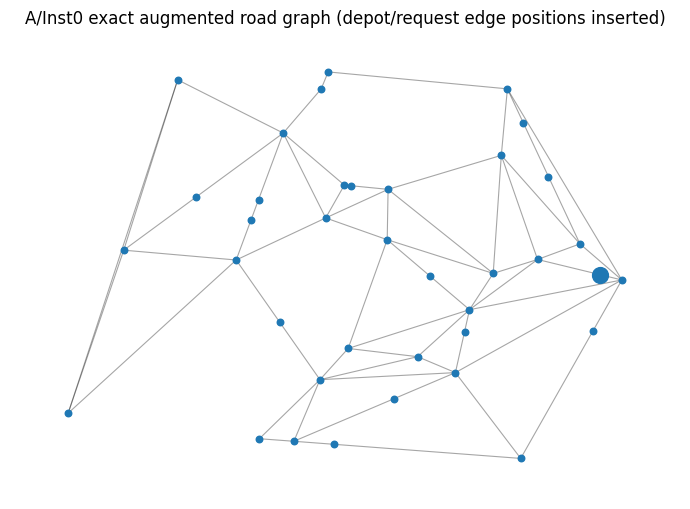

In [ ]:
# Cell 6 - Prepare train/validation/test instances and visualize an exact augmented road graph
def prepare(group,idx):
    d,G=load_raw(group,idx);H,depot,rnodes,nodereqs=augment_graph(d,G)
    active=np.array([float(r['t_rev'])<=0 for r in d['requests']])
    served=np.zeros(len(d['requests']),bool)
    x,nodes,nidx=build_features(d,H,depot,rnodes,active,served,0)
    ei,ea=edge_tensors(H,nodes)
    return {'group':group,'idx':idx,'d':d,'G':H,'depot':depot,'request_nodes':rnodes,'node_requests':nodereqs,'x0':x,'nodes':nodes,'nidx':nidx,'edge_index':ei,'edge_attr':ea}

TRAIN_IDS=list(range(0,10));VAL_IDS=list(range(10,15));TEST_IDS=list(range(20,25))
train_prepared=[prepare('A',i) for i in TRAIN_IDS]
val_prepared=[prepare('A',i) for i in VAL_IDS]
test_prepared=[prepare('A',i) for i in TEST_IDS]

split=pd.DataFrame({'Split':['Train','Validation','Test'],'A instance IDs':['0-9','10-14','20-24'],'Instances':[10,5,5]})
display(split)
p0=train_prepared[0]
print('Base A graph: 25 nodes / 54 edges')
print('Augmented A/Inst0:',p0['G'].number_of_nodes(),'nodes /',p0['G'].number_of_edges(),'edges')
print('Depot virtual/current node:',p0['depot'])
print('Request virtual nodes:',len(set(p0['request_nodes'].values())))

pos={n:get_xy(p0['G'],n) for n in p0['G'].nodes()}
fig,ax=plt.subplots(figsize=(7,5.2));nx.draw_networkx_edges(p0['G'],pos,ax=ax,alpha=.35,width=.8);nx.draw_networkx_nodes(p0['G'],pos,ax=ax,node_size=22)
nx.draw_networkx_nodes(p0['G'],pos,nodelist=[p0['depot']],ax=ax,node_size=130)
ax.set_title('A/Inst0 exact augmented road graph (depot/request edge positions inserted)');ax.set_axis_off();plt.tight_layout();plt.show()

## 2. Graph representation learning

The proposed encoder is a **3-layer sparse GAT with 8 heads and 128-dimensional node embeddings**. Edge travel length participates in attention. GraphSAGE is implemented separately only for the required GNN-PPO baseline.

In [ ]:
# Cell 7 - Sparse 3-layer GAT, GraphSAGE baseline, training, and incremental re-encoding
class SparseGATLayer(nn.Module):
    def __init__(self,in_dim,out_per_head,heads=8):
        super().__init__(); self.h=heads;self.d=out_per_head
        self.lin=nn.Linear(in_dim,heads*out_per_head,bias=False)
        self.a_src=nn.Parameter(torch.empty(heads,out_per_head));self.a_dst=nn.Parameter(torch.empty(heads,out_per_head))
        self.a_edge=nn.Parameter(torch.zeros(heads)); self.bias=nn.Parameter(torch.zeros(heads*out_per_head))
        nn.init.xavier_uniform_(self.lin.weight);nn.init.xavier_uniform_(self.a_src);nn.init.xavier_uniform_(self.a_dst)
    def forward(self,x,edge_index,edge_attr):
        N=x.size(0);h=self.lin(x).view(N,self.h,self.d);src,dst=edge_index
        hs=h[src];hd=h[dst]
        e=F.leaky_relu((hs*self.a_src).sum(-1)+(hd*self.a_dst).sum(-1)+edge_attr[:,None]*self.a_edge[None,:],0.2)
        ii=dst[:,None].expand(-1,self.h)
        m=torch.full((N,self.h),-1e9,device=x.device);m.scatter_reduce_(0,ii,e,reduce='amax',include_self=True)
        ex=torch.exp(e-m[dst]);den=torch.zeros((N,self.h),device=x.device);den.scatter_add_(0,ii,ex)
        a=ex/(den[dst]+1e-9);msg=a[...,None]*hs
        out=torch.zeros((N,self.h,self.d),device=x.device);out.index_add_(0,dst,msg)
        return out.reshape(N,self.h*self.d)+self.bias,a

class SparseGAT(nn.Module):
    def __init__(self,in_dim=9,embed_dim=128,heads=8,layers=3):
        super().__init__(); assert embed_dim%heads==0
        d=embed_dim//heads;self.layers=nn.ModuleList();cur=in_dim
        for _ in range(layers):self.layers.append(SparseGATLayer(cur,d,heads));cur=embed_dim
        self.embed_dim=embed_dim;self.heads=heads;self.depth=layers
    def forward(self,x,edge_index,edge_attr,return_attention=False):
        at=[]
        for li,L in enumerate(self.layers):
            x,a=L(x,edge_index,edge_attr);at.append(a)
            if li<len(self.layers)-1:x=F.elu(x)
        x=F.normalize(x,p=2,dim=-1)
        return (x,at) if return_attention else x

class GraphSAGE(nn.Module):
    def __init__(self,in_dim=9,embed_dim=128,layers=3):
        super().__init__();self.layers=nn.ModuleList();cur=in_dim
        for _ in range(layers):self.layers.append(nn.Linear(cur*2,embed_dim));cur=embed_dim
        self.embed_dim=embed_dim;self.depth=layers
    def forward(self,x,edge_index,edge_attr=None):
        src,dst=edge_index;N=x.size(0)
        for li,L in enumerate(self.layers):
            agg=torch.zeros_like(x);agg.index_add_(0,dst,x[src])
            cnt=torch.zeros(N,device=x.device);cnt.index_add_(0,dst,torch.ones_like(dst,dtype=torch.float32));agg=agg/(cnt[:,None]+1e-6)
            x=L(torch.cat([x,agg],-1));
            if li<len(self.layers)-1:x=F.relu(x)
        return F.normalize(x,p=2,dim=-1)

def contrastive_loss(z,edge_index,num_neg=None,margin=0.2):
    src,dst=edge_index
    mask=src!=dst;src=src[mask];dst=dst[mask]
    # unique directed okay
    pos=F.cosine_similarity(z[src],z[dst]);pos_loss=(1-pos).mean()
    n=num_neg or len(src); a=torch.randint(0,z.size(0),(n,));b=torch.randint(0,z.size(0),(n,))
    neg=F.cosine_similarity(z[a],z[b]);neg_loss=F.relu(neg-margin).mean()
    return pos_loss+0.5*neg_loss

def prepare(group,idx):
    d,G=load_raw(group,idx);H,depot,rnodes,nodereqs=augment_graph(d,G)
    active=np.array([float(r['t_rev'])<=0 for r in d['requests']])
    served=np.zeros(len(d['requests']),bool)
    x,nodes,nidx=build_features(d,H,depot,rnodes,active,served,0)
    ei,ea=edge_tensors(H,nodes)
    return {'group':group,'idx':idx,'d':d,'G':H,'depot':depot,'request_nodes':rnodes,'node_requests':nodereqs,'x0':x,'nodes':nodes,'nidx':nidx,'edge_index':ei,'edge_attr':ea}

def pretrain_encoder(model,instances,epochs=30,lr=2e-3):
    opt=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5);hist=[];model.train()
    for ep in range(epochs):
        total=0
        random.shuffle(instances)
        for p in instances:
            opt.zero_grad();z=model(p['x0'],p['edge_index'],p['edge_attr']);loss=contrastive_loss(z,p['edge_index']);loss.backward();opt.step();total+=loss.item()
        hist.append(total/len(instances))
    return hist

def k_hop_nodes(G,seeds,k):
    seen=set(seeds);front=set(seeds)
    for _ in range(k):
        nxt=set()
        for n in front:
            if n in G:nxt.update(G.neighbors(n))
        nxt-=seen;seen|=nxt;front=nxt
        if not front:break
    return seen

@torch.no_grad()
def encode_full(model,d,G,depot,rnodes,active,served,now):
    x,nodes,nidx=build_features(d,G,depot,rnodes,active,served,now);ei,ea=edge_tensors(G,nodes)
    z=model(x,ei,ea);return z,x,nodes,nidx,ei,ea

@torch.no_grad()
def incremental_reencode(model,d,oldG,newG,depot,rnodes,active,served,now,old_z,old_nodes,changed_nodes,depth=3):
    # exact local receptive-field recomputation for affected outputs by using an additional depth-hop context shell
    unionG=nx.compose(oldG,newG)
    outputs=k_hop_nodes(unionG,changed_nodes,depth)
    context=k_hop_nodes(unionG,outputs,depth)
    # Build dynamic node features on the FULL updated graph, then slice the local context.
    # This preserves global coordinate/degree normalization and makes local recomputation
    # numerically comparable with a full forward pass.
    x_full,new_nodes,new_idx=build_features(d,newG,depot,rnodes,active,served,now)
    sub=newG.subgraph(context).copy();nodes_sub=list(sub.nodes());idx_sub={n:i for i,n in enumerate(nodes_sub)}
    x_sub=torch.stack([x_full[new_idx[n]] for n in nodes_sub],dim=0)
    global_w=np.median([float(newG[u][v].get('weight',1.0)) for u,v in newG.edges()]) if newG.number_of_edges() else 1.0
    ei,ea=edge_tensors(sub,nodes_sub,weight_scale=global_w)
    t=time.perf_counter();z_sub=model(x_sub,ei,ea);lat=time.perf_counter()-t
    z_new=old_z.clone();global_idx={n:i for i,n in enumerate(old_nodes)}
    updated=0
    for n in outputs:
        if n in global_idx and n in idx_sub:
            z_new[global_idx[n]]=z_sub[idx_sub[n]];updated+=1
    return z_new,lat,outputs,context

# Actor / critics

GAT training: 1.660s | first loss=0.2229 | final loss=0.2199
GraphSAGE training: 0.409s | first loss=0.2541 | final loss=0.2213


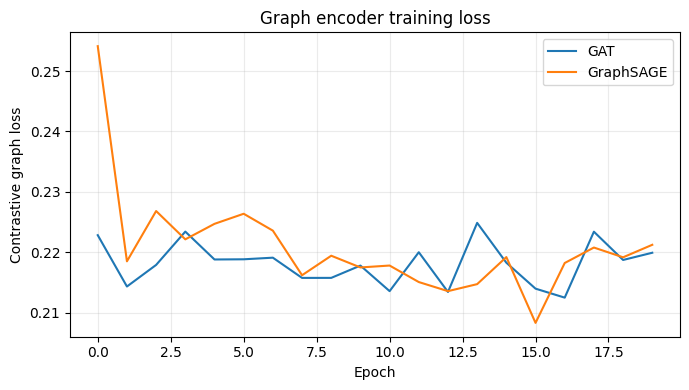

In [ ]:
# Cell 8 - Train GAT and GraphSAGE encoders on attached A-set training instances
GAT_LAYERS=3;ATTENTION_HEADS=8;EMBED_DIM=128
gat=SparseGAT(in_dim=9,embed_dim=EMBED_DIM,heads=ATTENTION_HEADS,layers=GAT_LAYERS)
gnn=GraphSAGE(in_dim=9,embed_dim=EMBED_DIM,layers=3)

t=time.perf_counter();gat_loss=pretrain_encoder(gat,train_prepared,epochs=20,lr=2e-3);gat_sec=time.perf_counter()-t
t=time.perf_counter();gnn_loss=pretrain_encoder(gnn,train_prepared,epochs=20,lr=2e-3);gnn_sec=time.perf_counter()-t
print(f'GAT training: {gat_sec:.3f}s | first loss={gat_loss[0]:.4f} | final loss={gat_loss[-1]:.4f}')
print(f'GraphSAGE training: {gnn_sec:.3f}s | first loss={gnn_loss[0]:.4f} | final loss={gnn_loss[-1]:.4f}')

fig,ax=plt.subplots(figsize=(7,4));ax.plot(gat_loss,label='GAT');ax.plot(gnn_loss,label='GraphSAGE');ax.set_title('Graph encoder training loss');ax.set_xlabel('Epoch');ax.set_ylabel('Contrastive graph loss');ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()

Embedding matrix: (39, 128)
GAT layers / heads / embedding dim: 3 8 128
Last-layer attention mean/std: 0.23076923191547394 0.08156147599220276


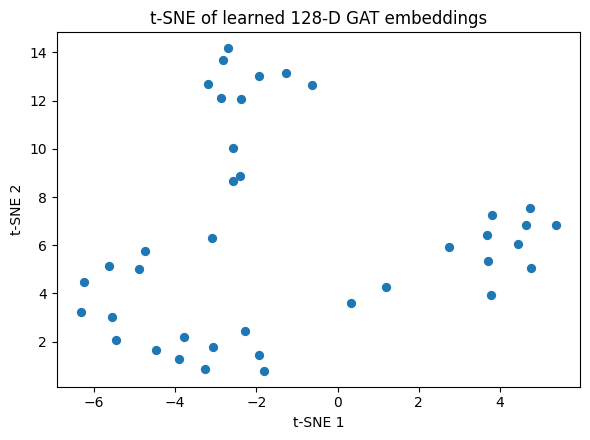

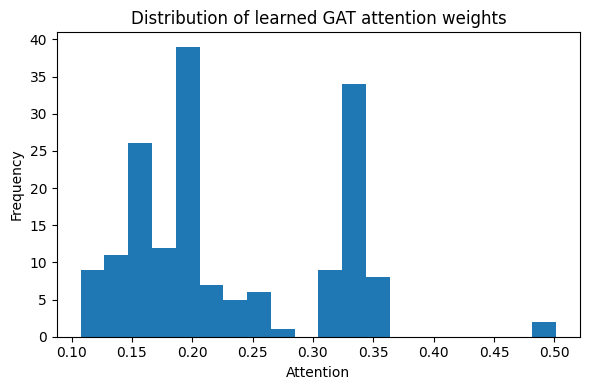

In [ ]:
# Cell 9 - GAT attention and t-SNE embedding analysis
p=test_prepared[0]
active=np.array([float(r['t_rev'])<=0 for r in p['d']['requests']],bool);served=np.zeros(len(active),bool)
x,nodes,nidx=build_features(p['d'],p['G'],p['depot'],p['request_nodes'],active,served,0)
ei,ea=edge_tensors(p['G'],nodes)
with torch.no_grad(): z,att=gat(x,ei,ea,return_attention=True)
print('Embedding matrix:',tuple(z.shape))
print('GAT layers / heads / embedding dim:',GAT_LAYERS,ATTENTION_HEADS,EMBED_DIM)
last_att=att[-1].mean(1).numpy()
print('Last-layer attention mean/std:',float(last_att.mean()),float(last_att.std()))

raw2=TSNE(n_components=2,random_state=SEED,perplexity=min(10,len(nodes)-1),init='pca',learning_rate='auto').fit_transform(x.numpy())
z2=TSNE(n_components=2,random_state=SEED,perplexity=min(10,len(nodes)-1),init='pca',learning_rate='auto').fit_transform(z.numpy())
fig,ax=plt.subplots(figsize=(6,4.5));ax.scatter(z2[:,0],z2[:,1],s=32);ax.set_title('t-SNE of learned 128-D GAT embeddings');ax.set_xlabel('t-SNE 1');ax.set_ylabel('t-SNE 2');plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(6,4));ax.hist(last_att,bins=20);ax.set_title('Distribution of learned GAT attention weights');ax.set_xlabel('Attention');ax.set_ylabel('Frequency');plt.tight_layout();plt.show()

## 3. Dynamic change detection and incremental graph re-encoding

A 3-layer GAT has a 3-hop receptive field. For a changed node/edge, the implementation marks the affected **3-hop output region**, obtains an additional **3-hop context shell**, re-encodes that local computation graph, and merges only affected outputs into the cached embedding matrix. Nodes outside the affected region retain their previous embeddings.

In [ ]:
# Cell 10 - Exact incremental-vs-full fidelity check on a real attached A instance
p=test_prepared[0]
active=np.array([False]*len(p['d']['requests']));served=np.zeros(len(active),bool)
z0,x0,nodes0,idx0,ei0,ea0=encode_full(gat,p['d'],p['G'],p['depot'],p['request_nodes'],active,served,0)
# Reveal one request -> localized node-feature change
active[0]=True;changed={p['request_nodes'][0]}
z_inc,inc_kernel,affected,context=incremental_reencode(gat,p['d'],p['G'],p['G'],p['depot'],p['request_nodes'],active,served,0,z0,nodes0,changed,gat.depth)
t=time.perf_counter();z_full,*_=encode_full(gat,p['d'],p['G'],p['depot'],p['request_nodes'],active,served,0);full_time=time.perf_counter()-t
ids=[idx0[n] for n in affected]
unaffected=[i for i,n in enumerate(nodes0) if n not in affected]
max_aff=float((z_inc[ids]-z_full[ids]).abs().max()) if ids else 0
max_unaff=float((z_inc[unaffected]-z_full[unaffected]).abs().max()) if unaffected else 0
check=pd.DataFrame({'Metric':['Graph nodes','Affected output nodes','Context nodes','Full GAT time (ms)','Local GAT kernel time (ms)','Unchanged embeddings preserved (%)','Max affected embedding error','Max unchanged embedding error'],
                    'Value':[len(nodes0),len(affected),len(context),full_time*1000,inc_kernel*1000,100*(len(nodes0)-len(affected))/len(nodes0),max_aff,max_unaff]})
display(check.round(6))

,Metric,Value
0,Graph nodes,39.000000
1,Affected output nodes,14.000000
2,Context nodes,38.000000
3,Full GAT time (ms),1.979848
4,Local GAT kernel time (ms),1.108805
5,Unchanged embeddings preserved (%),64.102564
6,Max affected embedding error,0.000000
7,Max unchanged embedding error,0.000000


,Graph nodes,Graph edges,Affected nodes,Context nodes,Full encoding (ms),Local GAT kernel (ms),End-to-end incremental (ms),Kernel speedup (x),E2E speedup (x),Preserved (%),Max embedding error
0,100,219,26,74,2.4445,1.5025,3.9373,1.6270,0.6209,74.00,0.0
1,1000,2199,26,97,43.3442,1.8181,12.3494,23.8400,3.5098,97.40,0.0
2,10000,21999,26,97,208.8464,1.8836,373.8481,110.8788,0.5586,99.74,0.0


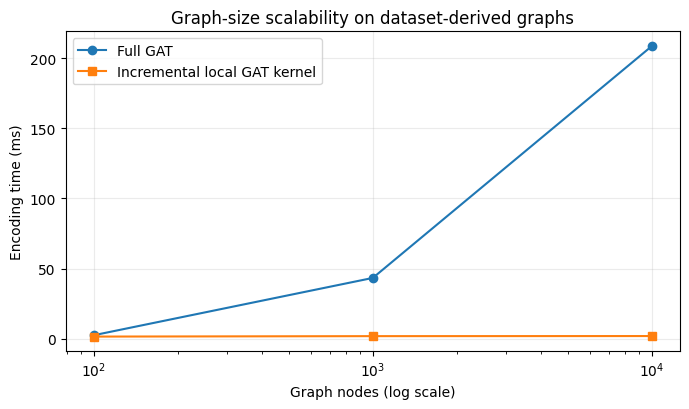

In [ ]:
# Cell 11 - Dataset-derived graph-size scalability: ~100 / 1,000 / 10,000 nodes
def scaled_from_dataset(base,target):
    n0=base.number_of_nodes();copies=target//n0
    if copies*n0!=target: raise ValueError('Target must be a multiple of base graph size (25).')
    nodes0=list(base.nodes());xs=[get_xy(base,n)[0] for n in nodes0];span=max(xs)-min(xs)+1.0
    med=float(np.median([base[u][v]['weight'] for u,v in base.edges()]));anchor=nodes0[0];H=nx.Graph()
    for c in range(copies):
        for n in nodes0:
            x,y=get_xy(base,n);H.add_node(f'{c}::{n}',x=x+c*span*1.2,y=y)
        for u,v in base.edges():H.add_edge(f'{c}::{u}',f'{c}::{v}',weight=float(base[u][v]['weight']))
        if c>0:H.add_edge(f'{c-1}::{anchor}',f'{c}::{anchor}',weight=med)
    return H,f'0::{anchor}'

d0,baseG=load_raw('A',0)
scale_rows=[]
for target in [100,1000,10000]:
    H,dep=scaled_from_dataset(baseG,target);rnodes={};active=np.zeros(len(d0['requests']),bool);served=np.zeros_like(active)
    z0,x0,nodes,idx,ei,ea=encode_full(gat,d0,H,dep,rnodes,active,served,0)
    old=H.copy();edge=list(H.edges())[len(H.edges())//2];H[edge[0]][edge[1]]['weight']*=2.0
    t=time.perf_counter();zinc,kernel,affected,context=incremental_reencode(gat,d0,old,H,dep,rnodes,active,served,0,z0,nodes,set(edge),gat.depth);inc_e2e=time.perf_counter()-t
    t=time.perf_counter();zfull,*_=encode_full(gat,d0,H,dep,rnodes,active,served,0);full=time.perf_counter()-t
    ids=[idx[n] for n in affected];err=float((zinc[ids]-zfull[ids]).abs().max()) if ids else 0
    scale_rows.append({'Graph nodes':target,'Graph edges':H.number_of_edges(),'Affected nodes':len(affected),'Context nodes':len(context),'Full encoding (ms)':full*1000,'Local GAT kernel (ms)':kernel*1000,'End-to-end incremental (ms)':inc_e2e*1000,'Kernel speedup (x)':full/max(kernel,1e-12),'E2E speedup (x)':full/max(inc_e2e,1e-12),'Preserved (%)':100*(target-len(affected))/target,'Max embedding error':err})
graph_scale=pd.DataFrame(scale_rows);display(graph_scale.round(4))
fig,ax=plt.subplots(figsize=(7,4.2));ax.plot(graph_scale['Graph nodes'],graph_scale['Full encoding (ms)'],marker='o',label='Full GAT');ax.plot(graph_scale['Graph nodes'],graph_scale['Local GAT kernel (ms)'],marker='s',label='Incremental local GAT kernel');ax.set_xscale('log');ax.set_title('Graph-size scalability on dataset-derived graphs');ax.set_xlabel('Graph nodes (log scale)');ax.set_ylabel('Encoding time (ms)');ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()

In [ ]:
# Cell 12 - Full vs incremental re-encoding across localized graph-change ratios
H,dep=scaled_from_dataset(baseG,1000);rnodes={};active=np.zeros(len(d0['requests']),bool);served=np.zeros_like(active)
zbase,xbase,nodes,idx,ei,ea=encode_full(gat,d0,H,dep,rnodes,active,served,0)
edges=list(H.edges());ratio_rows=[]
for ratio in [5,10,20,40,60,80,100]:
    Hnew=H.copy();k=max(1,int(len(edges)*ratio/100));chosen=edges[:k];changed=set()
    for u,v in chosen:Hnew[u][v]['weight']*=1.5;changed|={u,v}
    t=time.perf_counter();zinc,kernel,affected,context=incremental_reencode(gat,d0,H,Hnew,dep,rnodes,active,served,0,zbase,nodes,changed,gat.depth);e2e=time.perf_counter()-t
    t=time.perf_counter();zfull,*_=encode_full(gat,d0,Hnew,dep,rnodes,active,served,0);full=time.perf_counter()-t
    ids=[idx[n] for n in affected];err=float((zinc[ids]-zfull[ids]).abs().max()) if ids else 0
    ratio_rows.append({'Changed edges (%)':ratio,'Affected nodes (%)':100*len(affected)/len(nodes),'Full GAT (ms)':full*1000,'Incremental kernel (ms)':kernel*1000,'Incremental E2E (ms)':e2e*1000,'Kernel speedup (x)':full/max(kernel,1e-12),'Preserved embeddings (%)':100*(len(nodes)-len(affected))/len(nodes),'Max affected error':err})
change_ratio=pd.DataFrame(ratio_rows);display(change_ratio.round(4))

,Changed edges (%),Affected nodes (%),Full GAT (ms),Incremental kernel (ms),Incremental E2E (ms),Kernel speedup (x),Preserved embeddings (%),Max affected error
0,5,8.6,14.2189,2.1911,13.0388,6.4893,91.4,0.0
1,10,13.6,11.4868,2.5430,12.6983,4.5171,86.4,0.0
2,20,23.6,11.3322,3.1660,15.4765,3.5793,76.4,0.0
3,40,43.6,14.1468,5.7283,24.4066,2.4696,56.4,0.0
4,60,63.6,13.8835,6.8941,33.7181,2.0138,36.4,0.0
5,80,83.6,10.7228,8.2527,32.1317,1.2993,16.4,0.0
6,100,100.0,12.9274,4.0954,29.6611,3.1566,0.0,0.0


## 4. MAPPO and required PPO baselines

Every vehicle is an agent located at a real/virtual road node. At each decision step the actor receives the **feasible neighboring road segments**. A destination-aware feasibility mask retains neighbors that make shortest-path progress toward an active request; MAPPO still chooses among those road-neighbor actions. Waiting is allowed only when no request is active or when the vehicle is already at an active service node.

The proposed model uses a **centralized critic**; GAT-PPO and GNN-PPO use local critics. All models use the same road environment for a fair comparison.

In [ ]:
# Cell 13 - Neighbor actor, critics, road-routing environment, and PPO/MAPPO training
class NeighborActor(nn.Module):
    def __init__(self,cand_dim=10,ctx_dim=8,hidden=96):
        super().__init__();self.net=nn.Sequential(nn.Linear(cand_dim+ctx_dim,hidden),nn.Tanh(),nn.Linear(hidden,hidden),nn.Tanh(),nn.Linear(hidden,1))
    def forward(self,cand,ctx,mask):
        # cand [A,M,F], ctx [A,C]
        c=ctx[:,None,:].expand(-1,cand.size(1),-1);logits=self.net(torch.cat([cand,c],-1)).squeeze(-1)
        return logits.masked_fill(~mask,-1e9)
class CentralCritic(nn.Module):
    def __init__(self,dim=12,hidden=96):super().__init__();self.net=nn.Sequential(nn.Linear(dim,hidden),nn.Tanh(),nn.Linear(hidden,hidden),nn.Tanh(),nn.Linear(hidden,1))
    def forward(self,x):return self.net(x).squeeze(-1)
class LocalCritic(nn.Module):
    def __init__(self,dim=8,hidden=64):super().__init__();self.net=nn.Sequential(nn.Linear(dim,hidden),nn.Tanh(),nn.Linear(hidden,hidden),nn.Tanh(),nn.Linear(hidden,1))
    def forward(self,x):return self.net(x).squeeze(-1)

class RoadRoutingEnv:
    def __init__(self,p,encoder,encoding='static',max_steps=None,disruption=None):
        self.base=p;self.encoder=encoder;self.encoding=encoding;self.disruption=disruption
        self.max_steps=max_steps or max(180,12*len(p['d']['requests']))
        self.reset()
    def reset(self):
        p=self.base;self.d=copy.deepcopy(p['d']);self.G=p['G'].copy();self.depot=p['depot'];self.request_nodes=p['request_nodes'];self.node_requests=p['node_requests']
        self.N=len(self.d['requests']);self.A=int(self.d['num_vehicles']);self.served=np.zeros(self.N,bool)
        self.request_owner=np.arange(self.N,dtype=int)%max(self.A,1)
        self.use_assignment=self.A>1
        self.use_distance_matrix=self.G.number_of_nodes()<=600
        self.agent_nodes=[self.depot]*self.A;self.agent_time=np.zeros(self.A,np.float32);self.global_time=0.0
        self.distance=np.zeros(self.A,np.float32);self.delays=np.zeros(self.A,np.float32);self.service=np.zeros(self.A,np.float32);self.deliveries=np.zeros(self.A,int)
        self.routes=[[self.depot] for _ in range(self.A)];self.steps=0;self.adapt_latencies=[];self.disruption_done=False;self.disruption_event=None
        self.active=np.array([float(r['t_rev'])<=self.global_time for r in self.d['requests']],bool)
        self.z,self.x,self.nodes,self.nidx,self.ei,self.ea=encode_full(self.encoder,self.d,self.G,self.depot,self.request_nodes,self.active,self.served,self.global_time)
        self._refresh_distance_cache()
        self.prev_active=self.active.copy();self.last_changed_nodes=set();self.last_adapt=0.0;return self
    def _reencode(self,changed_nodes):
        if self.encoding=='static' or not changed_nodes:return 0.0
        # Node feature changes only; topology already stored in self.G. old graph == new graph for feature changes.
        if self.encoding=='incremental' and isinstance(self.encoder,SparseGAT):
            self.z,lat,outs,ctx=incremental_reencode(self.encoder,self.d,self.G,self.G,self.depot,self.request_nodes,self.active,self.served,self.global_time,self.z,self.nodes,set(changed_nodes),self.encoder.depth)
        else:
            t=time.perf_counter();self.z,self.x,self.nodes,self.nidx,self.ei,self.ea=encode_full(self.encoder,self.d,self.G,self.depot,self.request_nodes,self.active,self.served,self.global_time);lat=time.perf_counter()-t
        self.adapt_latencies.append(lat);self.last_adapt+=lat;return lat
    def _topology_reencode(self,oldG,changed_nodes):
        if self.encoding=='static':return 0.0
        if self.encoding=='incremental' and isinstance(self.encoder,SparseGAT):
            self.z,lat,outs,ctx=incremental_reencode(self.encoder,self.d,oldG,self.G,self.depot,self.request_nodes,self.active,self.served,self.global_time,self.z,self.nodes,set(changed_nodes),self.encoder.depth)
        else:
            t=time.perf_counter();self.z,self.x,self.nodes,self.nidx,self.ei,self.ea=encode_full(self.encoder,self.d,self.G,self.depot,self.request_nodes,self.active,self.served,self.global_time);lat=time.perf_counter()-t
        self.adapt_latencies.append(lat);self.last_adapt+=lat;return lat
    def _refresh_distance_cache(self):
        self.dist_nodes=list(self.G.nodes());self.dist_idx={n:i for i,n in enumerate(self.dist_nodes)};self.dist_matrix=None;self.target_dist_cache={}
        if self.use_distance_matrix:
            A=nx.to_scipy_sparse_array(self.G,nodelist=self.dist_nodes,weight='weight',dtype=float,format='csr')
            self.dist_matrix=np.asarray(sp_dijkstra(A,directed=False,unweighted=False))
    def _active_targets(self,request_ids=None):
        ids=range(self.N) if request_ids is None else request_ids
        return sorted({self.request_nodes[i] for i in ids if self.active[i] and not self.served[i]})
    def _dist_to_targets(self,request_ids=None):
        ts=self._active_targets(request_ids)
        if not ts:return {}
        if self.dist_matrix is not None:
            tids=[self.dist_idx[t] for t in ts if t in self.dist_idx]
            if not tids:return {}
            vals=np.min(self.dist_matrix[:,tids],axis=1)
            return {n:float(vals[i]) for i,n in enumerate(self.dist_nodes)}
        # Large graphs: route each agent toward one assigned request at a time and lazily cache
        # the single-target shortest-path map. This avoids repeated whole-network searches.
        t=ts[0]
        if t not in self.target_dist_cache:
            try:self.target_dist_cache[t]=nx.single_source_dijkstra_path_length(self.G,t,weight='weight')
            except:self.target_dist_cache[t]={}
        return self.target_dist_cache[t]
    def _urgency_at(self,n):
        vals=[];ub=max(float(self.d['upper_time_bound']),1)
        for i in self.node_requests.get(n,[]):
            if self.active[i] and not self.served[i]:
                r=self.d['requests'][i];deadline=float(r['t_desired'])+float(r['t_delay']);vals.append(max(0,(deadline-self.global_time)/ub))
        return min(vals) if vals else 1.0
    def observations(self):
        ub=max(float(self.d['upper_time_bound']),1.0)
        edge_ws=[float(self.G[u][v].get('weight',1.0)) for u,v in self.G.edges()];wscale=max(np.percentile(edge_ws,95) if edge_ws else 1,1e-6)
        active_unserved=[i for i in range(self.N) if self.active[i] and not self.served[i]]
        maxdeg=max([self.G.degree(n) for n in self.agent_nodes]+[1]);M=maxdeg+1 # wait slot
        cand=np.zeros((self.A,M,10),np.float32);mask=np.zeros((self.A,M),bool);choices=[]
        ctx=np.zeros((self.A,8),np.float32)
        occupancy=defaultdict(int)
        for n in self.agent_nodes:occupancy[n]+=1
        served_frac=float(self.served.mean()) if self.N else 1
        active_frac=len(active_unserved)/max(self.N,1)
        for a,n in enumerate(self.agent_nodes):
            agent_active=[i for i in active_unserved if (not self.use_assignment) or self.request_owner[i]==a]
            if self.dist_matrix is None and agent_active:
                agent_targets=[min(agent_active,key=lambda i:(float(self.d['requests'][i]['t_desired']),i))]
            else:
                agent_targets=agent_active
            distmap=self._dist_to_targets(agent_targets)
            active_nodes=[self.request_nodes[i] for i in agent_targets]
            if active_nodes:
                tids=[self.nidx[q] for q in active_nodes if q in self.nidx];target_centroid=self.z[tids].mean(0) if tids else torch.zeros(self.z.size(1))
            else:target_centroid=torch.zeros(self.z.size(1))
            neigh=list(self.G.neighbors(n));opts=[]
            curd=float(distmap.get(n,1e9));
            for k,m in enumerate(neigh):
                w=float(self.G[n][m].get('weight',1.0));md=float(distmap.get(m,1e9));progress=0 if not np.isfinite(curd) or not np.isfinite(md) else (curd-md)/wscale
                sim=float(F.cosine_similarity(self.z[self.nidx[m]][None,:],target_centroid[None,:]).item()) if active_nodes and m in self.nidx else 0
                is_active=float(any(self.active[i] and not self.served[i] for i in self.node_requests.get(m,[])))
                is_future=float(any((not self.active[i]) and (not self.served[i]) for i in self.node_requests.get(m,[])))
                cand[a,k]=[w/wscale,w/max(float(self.d['vehicle_speed']),1e-6)/ub,sim,min(md/(wscale*10),5.0) if np.isfinite(md) else 5.0,progress,is_active,is_future,float(m==self.depot),occupancy[m]/max(self.A,1),self._urgency_at(m)]
                mask[a,k]=True;opts.append(m)
            # Destination-feasibility mask: when requests are active, retain road-neighbor
            # actions that make strict shortest-path progress toward at least one active request.
            # The actor still chooses among feasible neighboring road segments.
            if len(agent_active)==0:
                mask[a,:len(neigh)] = False
            elif neigh:
                if curd<=1e-9:
                    mask[a,:len(neigh)] = False
                else:
                    progress_ok = cand[a,:len(neigh),4] > 1e-8
                    if progress_ok.any():
                        mask[a,:len(neigh)] = progress_ok
            # wait only when no active request, disconnected, or already at an active request node
            wk=len(neigh)
            cand[a,wk]=[0,0,0,0,0,0,0,float(n==self.depot),occupancy[n]/max(self.A,1),1]
            if len(agent_active)==0 or not neigh or curd<=1e-9:mask[a,wk]=True
            opts.append('__WAIT__');choices.append(opts)
            ctx[a]=[self.agent_time[a]/ub,served_frac,active_frac,self.distance[a]/(wscale*max(self.N,1)),self.deliveries[a]/max(self.N,1),self.G.degree(n)/max(maxdeg,1),self.global_time/ub,float(self.disruption_done)]
        return cand,ctx,mask,choices
    def global_state(self):
        ub=max(float(self.d['upper_time_bound']),1.0);active_unserved=sum(self.active & ~self.served);future=sum(~self.active & ~self.served)
        makespan=float(self.agent_time.max()) if self.A else 0
        return np.array([self.served.mean() if self.N else 1,active_unserved/max(self.N,1),future/max(self.N,1),self.global_time/ub,makespan/ub,float(self.distance.sum())/(max(self.N,1)*10),float(self.delays.sum())/(max(self.N,1)*ub),float(np.std(self.deliveries))/(max(self.N,1)),self.steps/max(self.max_steps,1),float(self.last_adapt*1000)/100,float(self.disruption_done),self.A/50],np.float32)
    def _choose_disrupt_edge(self):
        bridges={tuple(sorted(e)) for e in nx.bridges(self.G)}
        candidates=[]
        for u,v in self.G.edges():
            if tuple(sorted((u,v))) in bridges:continue
            if u.startswith('vp::') or v.startswith('vp::'):continue
            candidates.append((u,v))
        return candidates[0] if candidates else next(iter(self.G.edges()))
    def apply_disruption(self,kind):
        old=self.G.copy();changed=set();changed_edges=[]
        if kind=='new_request':
            fut=[i for i in range(self.N) if not self.active[i] and not self.served[i]]
            if fut:
                i=fut[-1];self.d['requests'][i]['t_rev']=self.global_time;self.active[i]=True;changed.add(self.request_nodes[i])
        elif kind=='edge_unavailable':
            u,v=self._choose_disrupt_edge();self.G.remove_edge(u,v);changed|={u,v};changed_edges.append((u,v,'removed'))
        elif kind=='travel_time_increase':
            u,v=self._choose_disrupt_edge();self.G[u][v]['weight']*=2.5;changed|={u,v};changed_edges.append((u,v,'x2.5'))
        elif kind=='request_change':
            cand=[i for i in range(self.N) if self.active[i] and not self.served[i]] or [i for i in range(self.N) if not self.served[i]]
            if cand:
                i=cand[0];oldn=self.request_nodes[i]
                alternatives=[self.request_nodes[j] for j in range(self.N) if j!=i and self.request_nodes[j]!=oldn]
                newn=alternatives[0] if alternatives else next(iter(self.G.neighbors(oldn)),oldn)
                if i in self.node_requests.get(oldn,[]): self.node_requests[oldn].remove(i)
                self.request_nodes[i]=newn;self.node_requests[newn].append(i)
                r=self.d['requests'][i];r['t_desired']=max(self.global_time,float(r['t_desired'])*0.7);r['t_delay']=max(1.0,float(r['t_delay'])*0.5)
                changed|={oldn,newn}
        elif kind=='multiple':
            # priority/request update + travel-time increase + reveal one future request
            cand=[i for i in range(self.N) if self.active[i] and not self.served[i]]
            if cand:
                i=cand[0];self.d['requests'][i]['t_delay']=max(1.0,float(self.d['requests'][i]['t_delay'])*0.5);changed.add(self.request_nodes[i])
            fut=[i for i in range(self.N) if not self.active[i] and not self.served[i]]
            if fut:self.d['requests'][fut[-1]]['t_rev']=self.global_time;self.active[fut[-1]]=True;changed.add(self.request_nodes[fut[-1]])
            u,v=self._choose_disrupt_edge();self.G[u][v]['weight']*=2.0;changed|={u,v};changed_edges.append((u,v,'x2'))
        self.disruption_done=True
        if changed_edges:self._refresh_distance_cache()
        lat=self._topology_reencode(old,changed) if changed_edges else self._reencode(changed)
        return {'kind':kind,'changed_nodes':len(changed),'changed_edges':len(changed_edges),'latency':lat}
    def step(self,actions,choices):
        self.steps+=1;self.last_adapt=0.0
        A=self.A;agent_r=np.zeros(A,np.float32);step_dist=np.zeros(A,np.float32);step_delay=np.zeros(A,np.float32);step_deliv=np.zeros(A,int);prev_times=self.agent_time.copy()
        # optional external disruption at a fixed decision step
        if self.disruption and (not self.disruption_done) and self.steps==self.disruption.get('step',8):self.disruption_event=self.apply_disruption(self.disruption['kind'])
        selected=[]
        for a,act in enumerate(actions):
            opts=choices[a];act=int(act);target=opts[act] if 0<=act<len(opts) else '__WAIT__';selected.append(target)
        # move agents
        for a,target in enumerate(selected):
            if target=='__WAIT__':continue
            n=self.agent_nodes[a]
            if not self.G.has_edge(n,target):agent_r[a]-=1.0;continue
            w=float(self.G[n][target].get('weight',1.0));dt=w/max(float(self.d['vehicle_speed']),1e-6)
            self.agent_nodes[a]=target;self.agent_time[a]+=dt;self.distance[a]+=w;step_dist[a]+=w;self.routes[a].append(target)
        self.global_time=float(max(self.agent_time.max(),self.global_time))
        # if everybody waited because no request active, jump clocks to next revelation
        if all(t=='__WAIT__' for t in selected):
            fut=[float(r['t_rev']) for i,r in enumerate(self.d['requests']) if not self.served[i] and not self.active[i]]
            if fut:
                nxt=min(fut);self.global_time=max(self.global_time,nxt);self.agent_time=np.maximum(self.agent_time,self.global_time)
        # activate newly revealed requests
        new_active=[]
        for i,r in enumerate(self.d['requests']):
            if (not self.active[i]) and float(r['t_rev'])<=self.global_time:
                self.active[i]=True;new_active.append(self.request_nodes[i])
        # service requests at occupied service nodes, resolve duplicate vehicles deterministically
        occupied=defaultdict(list)
        for a,n in enumerate(self.agent_nodes):occupied[n].append(a)
        changed=set(new_active)
        for n,agents in occupied.items():
            available=[i for i in self.node_requests.get(n,[]) if self.active[i] and not self.served[i]]
            for i in available:
                # choose earliest-arriving agent at the node
                a=min(agents,key=lambda q:self.agent_time[q]);r=self.d['requests'][i]
                start=max(float(self.agent_time[a]),float(r['t_desired']));delay=max(0.0,start-float(r['t_desired']))
                self.agent_time[a]=start+float(r['t_dur']);self.service[a]+=float(r['t_dur']);self.delays[a]+=delay;self.deliveries[a]+=1
                step_delay[a]+=delay;step_deliv[a]+=1;self.served[i]=True;changed.add(n)
        self.global_time=float(max(self.agent_time.max(),self.global_time))
        if changed:self._reencode(changed)
        # reward explicitly includes distance, route cost/delay, successful deliveries, and adaptation latency
        ub=max(float(self.d['upper_time_bound']),1.0);dist_scale=max(np.median([float(self.G[u][v].get('weight',1.0)) for u,v in self.G.edges()]),1e-6)
        step_time=np.maximum(self.agent_time-prev_times,0.0)
        for a in range(A):
            distance_term=float(self.d['alpha'])*step_dist[a]/dist_scale
            route_cost_term=(float(self.d['alpha'])*step_dist[a]/dist_scale + float(self.d['beta'])*step_delay[a]/ub + float(self.d['gamma'])*step_time[a]/ub)
            adaptation_term=(self.last_adapt*1000.0)
            agent_r[a]=(-0.05*distance_term -0.20*route_cost_term +2.0*step_deliv[a] -0.03*adaptation_term)
        team=float(agent_r.mean()) + 0.5*float(step_deliv.sum())
        done=bool(self.served.all() or self.steps>=self.max_steps)
        return team,agent_r,done


def discounted_returns(rs,gamma=.985):
    out=[];g=0
    for r in rs[::-1]:g=float(r)+gamma*g;out.append(g)
    return torch.tensor(out[::-1],dtype=torch.float32)

def train_mappo(prepared,encoder,episodes=80,ppo_epochs=3):
    actor=NeighborActor();critic=CentralCritic();ao=torch.optim.Adam(actor.parameters(),3e-4);co=torch.optim.Adam(critic.parameters(),8e-4);hist=[]
    for ep in range(episodes):
        env=RoadRoutingEnv(prepared[ep%len(prepared)],encoder,'incremental').reset();traj=[];rews=[]
        while True:
            cand,ctx,mask,choices=env.observations();gs=env.global_state();tc=torch.tensor(cand);tx=torch.tensor(ctx);tm=torch.tensor(mask)
            with torch.no_grad():
                logits=actor(tc,tx,tm);dist=Categorical(logits=logits);acts=dist.sample();logp=dist.log_prob(acts);val=critic(torch.tensor(gs)[None,:]).squeeze()
            team,ar,done=env.step(acts.numpy().tolist(),choices);traj.append((cand,ctx,mask,acts.numpy(),logp.numpy(),gs,float(val)));rews.append(team)
            if done:break
        R=discounted_returns(rews);V=torch.tensor([t[6] for t in traj]);adv=(R-V);adv=(adv-adv.mean())/(adv.std()+1e-6)
        for _ in range(ppo_epochs):
            pol=[];ent=[]
            for k,t in enumerate(traj):
                cand,ctx,mask,acts,oldlp,gs,_=t;logits=actor(torch.tensor(cand),torch.tensor(ctx),torch.tensor(mask));D=Categorical(logits=logits);nlp=D.log_prob(torch.tensor(acts));ratio=torch.exp(nlp-torch.tensor(oldlp));aa=adv[k];pol.append(-torch.min(ratio*aa,torch.clamp(ratio,.8,1.2)*aa).mean());ent.append(D.entropy().mean())
            loss=torch.stack(pol).mean()-0.01*torch.stack(ent).mean();ao.zero_grad();loss.backward();nn.utils.clip_grad_norm_(actor.parameters(),1);ao.step()
            gs=torch.tensor(np.stack([t[5] for t in traj]),dtype=torch.float32);pred=critic(gs);cl=F.mse_loss(pred,R);co.zero_grad();cl.backward();co.step()
        hist.append({'episode':ep+1,'reward':sum(rews),'actor_loss':float(loss.detach()),'critic_loss':float(cl.detach())})
    return actor,critic,pd.DataFrame(hist)

def train_ppo(prepared,encoder,episodes=65,ppo_epochs=3):
    actor=NeighborActor();critic=LocalCritic();ao=torch.optim.Adam(actor.parameters(),3e-4);co=torch.optim.Adam(critic.parameters(),8e-4);hist=[]
    for ep in range(episodes):
        env=RoadRoutingEnv(prepared[ep%len(prepared)],encoder,'full').reset();steps=[]
        # per-agent reward histories flattened by time later
        while True:
            cand,ctx,mask,choices=env.observations();tc=torch.tensor(cand);tx=torch.tensor(ctx);tm=torch.tensor(mask)
            with torch.no_grad():
                logits=actor(tc,tx,tm);D=Categorical(logits=logits);acts=D.sample();lp=D.log_prob(acts);val=critic(tx)
            team,ar,done=env.step(acts.numpy().tolist(),choices);steps.append((cand,ctx,mask,acts.numpy(),lp.numpy(),val.numpy(),ar.copy()))
            if done:break
        # returns for each agent
        T=len(steps);A=env.A;R=np.zeros((T,A),np.float32);g=np.zeros(A,np.float32)
        for t in range(T-1,-1,-1):g=steps[t][6]+.985*g;R[t]=g
        V=np.stack([s[5] for s in steps]);Adv=R-V;Adv=(Adv-Adv.mean())/(Adv.std()+1e-6)
        Rt=torch.tensor(R)
        for _ in range(ppo_epochs):
            pol=[];ents=[];vals=[]
            for t,s in enumerate(steps):
                cand,ctx,mask,acts,oldlp,_,_=s;logits=actor(torch.tensor(cand),torch.tensor(ctx),torch.tensor(mask));D=Categorical(logits=logits);nlp=D.log_prob(torch.tensor(acts));ratio=torch.exp(nlp-torch.tensor(oldlp));aa=torch.tensor(Adv[t]);pol.append(-torch.min(ratio*aa,torch.clamp(ratio,.8,1.2)*aa).mean());ents.append(D.entropy().mean());vals.append(critic(torch.tensor(ctx)))
            pl=torch.stack(pol).mean()-0.01*torch.stack(ents).mean();ao.zero_grad();pl.backward();nn.utils.clip_grad_norm_(actor.parameters(),1);ao.step()
            pred=torch.stack(vals);cl=F.mse_loss(pred,Rt);co.zero_grad();cl.backward();co.step()
        hist.append({'episode':ep+1,'reward':float(R[0].mean()),'actor_loss':float(pl.detach()),'critic_loss':float(cl.detach())})
    return actor,critic,pd.DataFrame(hist)

In [ ]:
# Cell 14 - Inspect the exact road-neighbor action space and active reward terms
probe=RoadRoutingEnv(train_prepared[0],gat,'incremental').reset()
# Advance to the first request-revelation time so the action mask exposes road-neighbor choices.
first_rev=min(float(r['t_rev']) for r in probe.d['requests'])
probe.global_time=first_rev
probe.agent_time[:]=first_rev
newly=[]
for i,r in enumerate(probe.d['requests']):
    if float(r['t_rev'])<=probe.global_time and not probe.active[i]:
        probe.active[i]=True; newly.append(probe.request_nodes[i])
if newly: probe._reencode(set(newly))
cand,ctx,mask,choices=probe.observations()
print('Vehicles:',probe.A,'| first active request time:',round(first_rev,4))
for a in range(min(probe.A,3)):
    valid=[choices[a][j] for j in range(len(choices[a])) if mask[a,j]]
    current=probe.agent_nodes[a]
    actual_neighbors=set(probe.G.neighbors(current))
    print(f'Agent {a} current node={current}')
    print('  graph neighbors:',sorted(actual_neighbors)[:12])
    print('  feasible policy actions:',valid)
    assert all((v=='__WAIT__' or v in actual_neighbors) for v in valid), 'Action is not an adjacent road node.'
print('\nCandidate feature columns: edge distance, edge travel time, GAT similarity, nearest-request distance, progress, active-request flag, future-request flag, depot flag, occupancy, urgency')
print('Context shape:',ctx.shape,'| Centralized state shape:',probe.global_state().shape)
print('Incremental re-encoding events already triggered:',len(probe.adapt_latencies))
print('Latest measured adaptation latency (ms):',round(1000*probe.adapt_latencies[-1],4) if probe.adapt_latencies else 0.0)
print('Reward uses: travel distance + weighted route cost/time/delay + successful delivery - adaptation-latency penalty.')


In [ ]:
# Cell 15 - Train proposed MAPPO and the two required PPO baselines
# No paper result is hard-coded. MAPPO trains with incremental re-encoding enabled, so measured adaptation latency is an active reward term.
# PPO baselines use full graph re-encoding on state changes for a fair conventional comparison.
t=time.perf_counter();mappo_actor,mappo_critic,mappo_hist=train_mappo(train_prepared,gat,episodes=30,ppo_epochs=3);mappo_train_sec=time.perf_counter()-t
t=time.perf_counter();gatppo_actor,gatppo_critic,gatppo_hist=train_ppo(train_prepared,gat,episodes=25,ppo_epochs=3);gatppo_train_sec=time.perf_counter()-t
t=time.perf_counter();gnnppo_actor,gnnppo_critic,gnnppo_hist=train_ppo(train_prepared,gnn,episodes=25,ppo_epochs=3);gnnppo_train_sec=time.perf_counter()-t
print(f'Incremental GAT-MAPPO training time: {mappo_train_sec:.2f}s')
print(f'GAT-PPO training time: {gatppo_train_sec:.2f}s')
print(f'GNN-PPO training time: {gnnppo_train_sec:.2f}s')
display(mappo_hist.tail())
display(gatppo_hist.tail())
display(gnnppo_hist.tail())

In [ ]:
# Cell 16 - MAPPO/PPO training curves
fig,ax=plt.subplots(figsize=(7,4));ax.plot(mappo_hist['episode'],mappo_hist['reward'],label='Incremental GAT-MAPPO');ax.plot(gatppo_hist['episode'],gatppo_hist['reward'],label='GAT-PPO');ax.plot(gnnppo_hist['episode'],gnnppo_hist['reward'],label='GNN-PPO');ax.set_title('RL training reward');ax.set_xlabel('Episode');ax.set_ylabel('Episode reward');ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(7,4));ax.plot(mappo_hist['episode'],mappo_hist['critic_loss'],label='MAPPO centralized critic');ax.plot(gatppo_hist['episode'],gatppo_hist['critic_loss'],label='GAT-PPO local critic');ax.plot(gnnppo_hist['episode'],gnnppo_hist['critic_loss'],label='GNN-PPO local critic');ax.set_title('Critic optimization loss');ax.set_xlabel('Episode');ax.set_ylabel('MSE loss');ax.set_yscale('log');ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()